<a href="https://colab.research.google.com/github/hwasun-zip/health-diet-recommender/blob/main/health_diet_recommender.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [17]:

try:
    import google.colab
    !apt-get -qq install fonts-nanum
    from google.colab import drive; drive.mount('/content/drive')
    DATA_DIR = "/content/drive/MyDrive/nutri_data"   # CSV 2개 넣은 폴더
except Exception:
    DATA_DIR = "."

import pandas as pd, numpy as np, glob
from sklearn.preprocessing import RobustScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from scipy.stats import zscore
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
def read_any(path):
    for enc in ("utf-8-sig","cp949","utf-8"):
        try: return pd.read_csv(path, encoding=enc, dtype=str)
        except UnicodeDecodeError: continue
    raise ValueError("인코딩 실패: "+path)

files = glob.glob(f"{DATA_DIR}/*.csv")     # ← 한글 패턴 대신 *.csv
print("찾은 파일:", [f.split('/')[-1] for f in files])
df = pd.concat([read_any(f) for f in files], ignore_index=True)
print("통합 데이터:", df.shape)
df[["식품명","식품대분류명","에너지(kcal)","단백질(g)","지방(g)","탄수화물(g)","나트륨(mg)"]].head()

찾은 파일: ['해양수산부_국립수산과학원_통합식품영양성분정보(원재료성식품)_20260113.csv', '농촌진흥청_국립식량과학원_통합식품영양성분정보(원재료성식품)_20251223.csv']
통합 데이터: (3704, 53)


,식품명,식품대분류명,에너지(kcal),단백질(g),지방(g),탄수화물(g),나트륨(mg)
0,가라지류_가라지_육_생것_여수_6월,어패류 및 기타 수산물,78,14.81,1.30,0.69,NaN
1,가리비류_가리비_관자(패주)_삶아서 말린것_대표_평균,어패류 및 기타 수산물,334,65.70,1.40,7.60,2500
2,가리비류_가리비_관자(패주)_생것_대표_평균,어패류 및 기타 수산물,91,16.90,0.30,3.50,120
3,가리비류_가리비_육_말린것_대표_평균,어패류 및 기타 수산물,387,77.60,0.40,4.40,2300
4,가리비류_가리비_육_삶은것_대표_평균,어패류 및 기타 수산물,99,17.60,1.90,1.90,250


In [6]:
NUM = ["에너지(kcal)","단백질(g)","지방(g)","탄수화물(g)","당류(g)","식이섬유(g)",
       "나트륨(mg)","칼륨(mg)","인(mg)","콜레스테롤(mg)","포화지방산(g)"]
for c in NUM: df[c] = pd.to_numeric(df[c], errors="coerce")

CORE = ["에너지(kcal)","단백질(g)","지방(g)","탄수화물(g)","나트륨(mg)"]
d = df.dropna(subset=CORE).copy()
print("정제 후:", d.shape)
print(d["식품대분류명"].value_counts().head(8).to_string())

정제 후: (2250, 53)
식품대분류명
채소류             516
어패류 및 기타 수산물    424
육류              389
곡류              268
과일류             189
버섯류              89
감자 및 전분류         62
두류               58


In [7]:
d = d[d["나트륨(mg)"] < 20000].copy()      # 순수 소금류 제외
d["나트륨_log"] = np.log1p(d["나트륨(mg)"])   # 나트륨 로그변환
FEAT = ["에너지(kcal)","단백질(g)","지방(g)","탄수화물(g)","나트륨_log"]
Xs = RobustScaler().fit_transform(d[FEAT].values)

for k in range(2, 9):
    lab = KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(Xs)
    print(f"k={k}: silhouette={silhouette_score(Xs, lab):.3f}")

k=2: silhouette=0.752
k=3: silhouette=0.508
k=4: silhouette=0.512
k=5: silhouette=0.498
k=6: silhouette=0.501
k=7: silhouette=0.499
k=8: silhouette=0.503


In [8]:
km = KMeans(n_clusters=5, random_state=42, n_init=10).fit(Xs)
d["군집"] = km.labels_

prof = d.groupby("군집")[["에너지(kcal)","단백질(g)","지방(g)","탄수화물(g)","나트륨(mg)"]].mean().round(1)
def label(r):
    if r["지방(g)"]>50: return "초고지방(유지·견과)"
    if r["탄수화물(g)"]>50: return "고탄수화물(곡류)"
    if r["에너지(kcal)"]<80: return "저칼로리(채소·과일)"
    if r["지방(g)"]>20: return "고단백·고지방"
    return "고단백·저지방"
names = {c: label(prof.loc[c]) for c in prof.index}
d["군집명"] = d["군집"].map(names)
prof["군집명"] = [names[c] for c in prof.index]
prof["개수"] = d["군집"].value_counts().sort_index()
prof

,에너지(kcal),단백질(g),지방(g),탄수화물(g),나트륨(mg),군집명,개수
군집,,,,,,,
0,326.0,11.2,2.3,70.9,96.5,고탄수화물(곡류),389
1,156.1,21.6,5.9,2.8,463.7,고단백·저지방,707
2,363.8,20.5,27.9,8.2,105.2,고단백·고지방,202
3,841.6,3.8,90.8,4.0,4.5,초고지방(유지·견과),33
4,52.7,2.5,0.4,11.3,28.2,저칼로리(채소·과일),910


In [10]:
import matplotlib.font_manager as fm
fpath = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
fm.fontManager.addfont(fpath)                                  # 폰트 등록
plt.rcParams['font.family'] = fm.FontProperties(fname=fpath).get_name()
plt.rcParams['axes.unicode_minus'] = False
print("폰트 설정 완료:", plt.rcParams['font.family'])

폰트 설정 완료: ['NanumGothic']


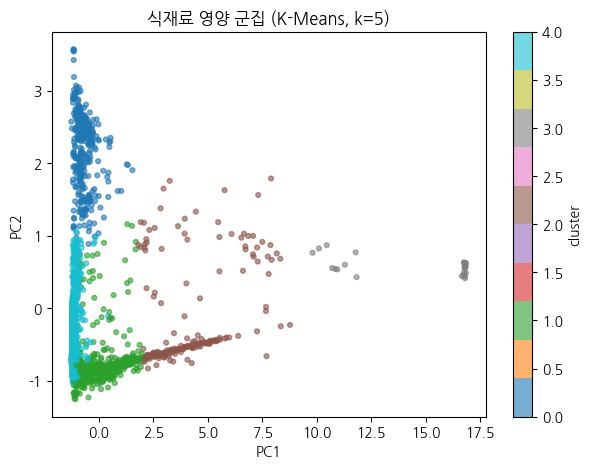

In [11]:
p = PCA(n_components=2).fit_transform(Xs)
plt.figure(figsize=(7,5))
sc = plt.scatter(p[:,0], p[:,1], c=d["군집"], cmap="tab10", s=12, alpha=0.6)
plt.title("식재료 영양 군집 (K-Means, k=5)")
plt.xlabel("PC1"); plt.ylabel("PC2"); plt.colorbar(sc, label="cluster"); plt.show()

In [13]:
for c in NUM: d[c] = d[c].fillna(d[c].median())
Z = d[NUM].apply(zscore)

DISEASE = {
 "당뇨":   {"penalize":{"당류(g)":2.0,"탄수화물(g)":1.0}, "prefer":{"식이섬유(g)":1.0}},
 "고혈압": {"penalize":{"나트륨(mg)":2.5}, "prefer":{"칼륨(mg)":1.0,"식이섬유(g)":0.5}},
 "고지혈증":{"penalize":{"포화지방산(g)":2.0,"콜레스테롤(mg)":1.5}, "prefer":{"식이섬유(g)":1.0}},
 "신장질환":{"penalize":{"나트륨(mg)":1.5,"칼륨(mg)":2.0,"인(mg)":2.0}, "prefer":{}},
 "비만":   {"penalize":{"에너지(kcal)":1.5,"지방(g)":1.0}, "prefer":{"단백질(g)":0.8,"식이섬유(g)":0.8}},
 "통풍":   {"penalize":{}, "prefer":{}, "exclude_group":["어패류 및 기타 수산물","육류"]},
}
ALLERGY = {
 "우유":["우유","치즈","버터","유청","크림"],"난류":["달걀","계란","전란","난황","난백","메추리알"],
 "땅콩":["땅콩"],"대두":["대두","두부","콩","된장","두유"],"밀":["밀","소맥","글루텐"],"메밀":["메밀"],
 "갑각류":["새우","게_","꽃게","대게","가재","크릴","바닷가재"],
 "조개류":["굴","전복","홍합","조개","가리비","바지락","꼬막"],
 "견과류":["호두","잣","아몬드","캐슈","피스타치오","헤이즐넛","개암","마카다미아","브라질너트"],
 "복숭아":["복숭아"],"토마토":["토마토"],"돼지고기":["돼지"],"쇠고기":["쇠고기","우육"],"닭고기":["닭"],
}
BAD_FORM = ["말린것","건조","분말","가루","동결","농축","추출","튀김","조미","시럽","페이스트"]
BAD_PART = ["쌀눈","배아","싹","순_","눈_"]
ROLE = {"밥·탄수화물":["곡류","감자 및 전분류"],
        "단백질원":["육류","어패류 및 기타 수산물","난류","두류","우유류"],
        "채소·과일":["채소류","버섯류","해조류","과일류"]}

In [15]:
def recommend(diseases=(), allergies=(), topn=5, verbose=True):
    r = d[~d["식품명"].str.contains("|".join(BAD_FORM), na=False)].copy()
    for a in allergies:
        for kw in ALLERGY.get(a, []):
            r = r[~r["식품명"].str.contains(kw, na=False)]
    score = pd.Series(0.0, index=r.index)
    for dis in diseases:
        cfg = DISEASE.get(dis, {})
        for col,w in cfg.get("penalize",{}).items(): score -= w*Z.loc[r.index,col]
        for col,w in cfg.get("prefer",{}).items():   score += w*Z.loc[r.index,col]
        for g in cfg.get("exclude_group",[]):        score -= 1.5*(r["식품대분류명"]==g).astype(float)
    r = r.assign(적합도=score)
    out = {}
    if verbose: print(f"■ 질환:{list(diseases) or '없음'} / 알레르기:{list(allergies) or '없음'}")
    for role, groups in ROLE.items():
        sub = r[r["식품대분류명"].isin(groups)]
        if role == "밥·탄수화물":
            sub = sub[~sub["식품명"].str.contains("|".join(BAD_PART), na=False)]
        sub = sub.nlargest(topn, "적합도")
        out[role] = sub
        if verbose:
            print(f"\n[{role}] TOP{topn}")
            print(sub[["식품명","식품대분류명","에너지(kcal)","단백질(g)","나트륨(mg)","적합도"]].round(2).to_string(index=False))
    if verbose:
        combo = " + ".join(out[r0].iloc[0]["식품명"].split("_")[0] for r0 in ROLE if len(out[r0]))
        print(f"\n★ 추천 한 끼 조합: {combo}")
    return out

In [16]:
_ = recommend(diseases=["고혈압","당뇨"], allergies=["갑각류"])
_ = recommend(diseases=["신장질환"])
_ = recommend(diseases=["고지혈증","비만"], allergies=["대두"])

■ 질환:['고혈압', '당뇨'] / 알레르기:['갑각류']

[밥·탄수화물] TOP5
            식품명   식품대분류명  에너지(kcal)  단백질(g)  나트륨(mg)  적합도
  보리_흑수청찰_조곡_생것       곡류        349   11.64      7.0 2.15
   보리_겉보리_조곡_생것       곡류        347   11.01      7.0 2.06
   보리_늘보리_도정_생것       곡류        346    9.79      6.0 2.02
보리_큰알보리1호_조곡_생것       곡류        345   10.39      6.0 1.97
          토란_생것 감자 및 전분류         71    2.08      2.0 1.28

[단백질원] TOP5
                 식품명       식품대분류명  에너지(kcal)  단백질(g)  나트륨(mg)  적합도
     쥐눈이콩(검정소립콩)_볶은것           두류        447   42.31      3.0 5.58
송어류_무지개송어_육_생것_대표_평균 어패류 및 기타 수산물        166   20.60    282.0 5.29
        콩(대두)_흑태_볶은것           두류        446   40.99      6.0 5.00
       콩(대두)_노란콩_볶은것           두류        444   40.47      3.0 4.82
       콩(대두)_서리태_볶은것           두류        436   41.72      4.0 4.42

[채소·과일] TOP5
           식품명 식품대분류명  에너지(kcal)  단백질(g)  나트륨(mg)  적합도
염교(락교)_뿌리줄기_생것    채소류         83    1.40      2.0 3.81
     홑잎나물_순_생것    채소류         96    4.77      1.0 2.95
      꾸지뽕